# Sampling Distributions

From: https://brilliant.org/wiki/inverse-transform-sampling/

How do we programmatically sample from a given probability distribution?
We usually just have access to random number generators in code, so we need a
way to map u[0,1]->x(from pdf).

In this notebook I implement this sampling method, whereby x = cdf^-1(u).

In [214]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from random import random

In [2]:
def pdf(x):
    return (x + 1)/2

def cdf(x):
    return (x**2)/4 + x/2 + 1/4

def inverse_cdf(u):
    return 2 * np.sqrt(u) -1

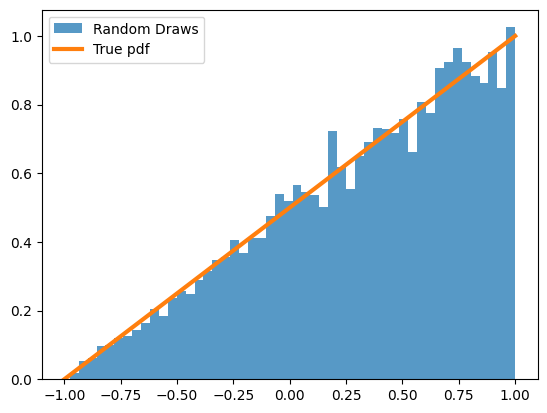

In [13]:
n = 10000
x_arr = []
for i in range(n):
    u = random()
    x = inverse_cdf(u)
    x_arr.append(x)

plt.hist(x_arr, bins=50, density=True, label="Random Draws", alpha=0.75)

xs = np.linspace(-1,1,100)
plt.plot(xs, pdf(xs), linewidth=3, label="True pdf")
plt.legend();

## Lengendre

In [154]:
# for legendre polynomails x in cosine(theta), with theta the scattering
# angle of the neutrons from 0 degrees in our case

def P0(x):
    return 1

def P2(x):
    return (1/2) * (3 * (x**2) - 1)

def P4(x):
    return (1/8) * (35 * (x**4) - 30 * (x**2) + 3)

def P6(x):
    return (1/16) * (231 * (x**6) - 315 * (x**4) + 105 * (x**2) - 5)

def dd_legendre_polynomial(mu): # mu=cos(theta)
    A0 = 0.758
    A2 = 0.241
    A4 = 0.001
    return (A0*P0(mu) + A2*P2(mu) + A4*P4(mu))

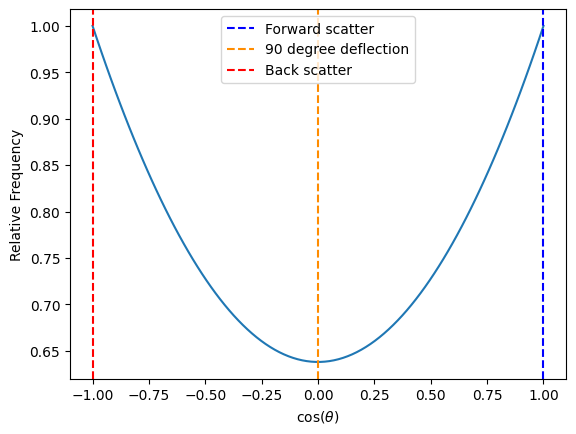

In [172]:
mus = np.linspace(-1,1,100)
plt.plot(mus, dd_legendre_polynomial(mus));
plt.xlabel(rf"$\cos(\theta)$")
plt.ylabel("Relative Frequency")
plt.axvline(1, linestyle = '--', label="Forward scatter", color='blue')
plt.axvline(0, linestyle = '--', label="90 degree deflection", color='darkorange')
plt.axvline(-1, linestyle = '--', label="Back scatter", color='red')
plt.legend();

In [244]:
n = 1000000
mu_samples = []
for i in range(n):
    while True:
        mu = 2*random() - 1
        fx = dd_legendre_polynomial(mu)
        y = random()
        if y <= fx:
            mu_samples.append(mu)
            break

mu_samples = np.array(mu_samples)
phi_samples = 2*np.pi*np.random.random(n)

sin_thetas = np.sqrt(1 - mu_samples**2)

x_dirs = mu_samples
y_dirs = sin_thetas * np.cos(phi_samples)
z_dirs = sin_thetas * np.sin(phi_samples)

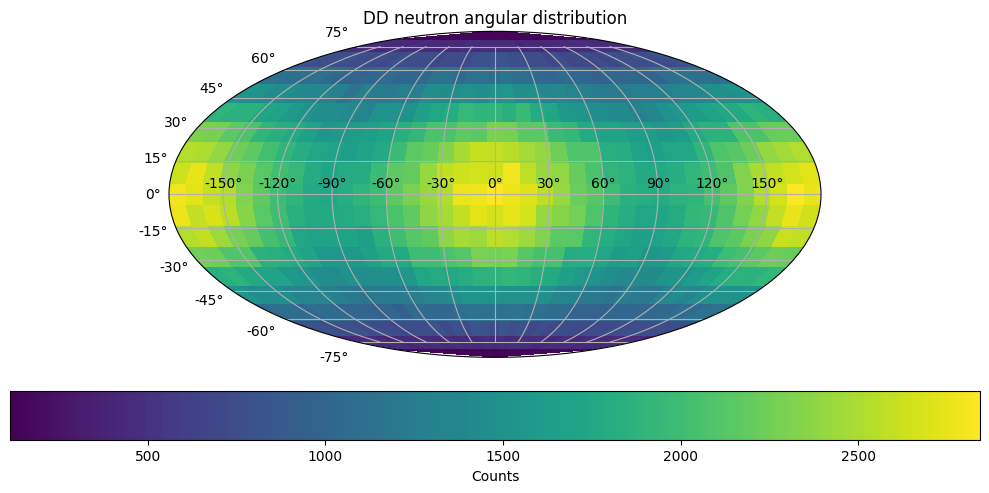

In [245]:
lon = np.arctan2(y_dirs, x_dirs)   # range [-pi, pi]
lat = np.arcsin(z_dirs)            # range [-pi/2, pi/2]

n_lon = 40
n_lat = 20

lon_edges = np.linspace(-np.pi, np.pi, n_lon)
lat_edges = np.linspace(-np.pi/2, np.pi/2, n_lat)

H, _, _ = np.histogram2d(lon, lat, bins=[lon_edges, lat_edges])

# For pcolormesh we need bin edges as 2D arrays
LON, LAT = np.meshgrid(lon_edges, lat_edges)

fig = plt.figure(figsize=(10, 5))
ax = fig.add_subplot(111, projection="mollweide")

pcm = ax.pcolormesh(LON, LAT, H.T, shading="auto")

fig.colorbar(pcm, ax=ax, orientation="horizontal", pad=0.08, label="Counts")

ax.grid(True)
ax.set_title("DD neutron angular distribution")

plt.tight_layout()
plt.show()